In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
import glob
import pandas as pd
import numpy as np
import astropy.units as u
from datetime import date
from random import choices, seed
from math import factorial, erf
from astroquery.simbad import Simbad
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm, uniform, truncnorm
from scipy.special import erfinv, comb
from scipy.special import comb
import h5py
from sklearn.neighbors import KernelDensity
# from scipy.integrate import simps
from scipy import stats
from matplotlib.ticker import AutoMinorLocator
from astropy.io import ascii
from IPython.display import clear_output
import time
from scipy.signal import find_peaks


In [3]:
def make_cmap(colors, position, bit=False):
    '''
    make_cmap takes a list of tuples which contain RGB values. The RGB
    values may either be in 8-bit [0 to 255] (in which bit must be set to
    True when called) or arithmetic [0 to 1] (default). make_cmap returns
    a cmap with equally spaced colors.
    Arrange your tuples so that the first color is the lowest value for the
    colorbar and the last is the highest.
    position contains values from 0 to 1 to dictate the location of each color.
    '''
    bit_rgb = np.linspace(0,1,256)
    # if position == None:
    #     position = np.linspace(0,1,len(colors))
    # else:
    if len(position) != len(colors):
        sys.exit("position length must be the same as colors")
    elif position[0] != 0 or position[-1] != 1:
        sys.exit("position must start with 0 and end with 1")
    if bit:
        for i in range(len(colors)):
            colors[i] = (bit_rgb[colors[i][0]],
                         bit_rgb[colors[i][1]],
                         bit_rgb[colors[i][2]])
    cdict = {'red':[], 'green':[], 'blue':[]}
    for pos, color in zip(position, colors):
        cdict['red'].append((pos, color[0], color[0]))
        cdict['green'].append((pos, color[1], color[1]))
        cdict['blue'].append((pos, color[2], color[2]))

    cmap = mpl.colors.LinearSegmentedColormap('my_colormap',cdict,256)
    return cmap
def choose_cmap(custom_cmap, reverse_cmap=False):

    custom_cmaps = {'primordial disks': [(0/255, 26/255, 26/255),
                                         (41/255, 163/255, 163/255),
                                         (179/255, 255/255, 217/255)],
                    'debris disks': [(15/255, 15/255, 62/255),
                                      (102/255, 102/255, 255/255),
                                      (255/255, 204/255, 255/255)],
                    'hot jupiters': [(15/255, 15/255, 62/255),
                                     (102/255, 102/255, 255/255),
                                     (255/255, 250/255, 255/255)],
                    'warm jupiters': [(51/255, 26/255, 0/255),
                                      (255/255, 80/255, 80/255),
                                      (255/255, 255/255, 204/255)],
                    'cyber grape': [(51/255, 0/255, 51/255),
                                    (128/255, 0/255, 128/255),
                                    (153/255, 102/255, 255/255),
                                    (204/255, 255/255, 255/255)],
                    'raspberry punch1': [(51/255, 0/255, 102/255),
                                        (51/255, 204/255, 224/255),
                                        (248/255, 255/255, 230/255)],
                    'raspberry punch2': [(70/255, 0/255, 0/255),
                                        (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    'raspberry punch': [(51/255, 0/255, 102/255),
                                        # (89/255, 0/255, 179/255),
                                        (51/255, 204/255, 224/255),
                                        (255/255, 255/255, 200/255)],
                    }

    chosen_cmap = custom_cmaps[custom_cmap]
    pos_diff = 1./(len(chosen_cmap)-1)
    positions = np.arange(0, 1+pos_diff, pos_diff)
    if reverse_cmap == True:
        chosen_cmap = chosen_cmap[::-1]
    mycolormap = make_cmap(chosen_cmap, position=positions)

    return mycolormap
def sorted_alphanumeric(list_to_sort):
    """
    Description: Sorts contents of the list alphanumerically (e.g., A1, A2, B2, A10) rather than naturally (e.g., A1, A10, A2, B2)
                 because the built-in python function "sorted()" does not do this without providing a key.
    Arguments: list_to_sort = List containing items to sort.
    Returns: List containing sorted items.
    """

    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]

    return sorted(list_to_sort, key=alphanum_key)

plt.style.use('/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle')
# plt.rcParams.keys()

Bad value in file '/Users/lb8137/Projects/mpl_stylefiles/mystyle.mplstyle', line 17 ("mathtext.fallback: dejavsans  # Select fallback font from ['cm' (Computer Modern), 'stix'"): Key mathtext.fallback: dejavsans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [9]:
def draw_data_for_kde(Prob_distributions, posterior_x_values, kde_n_draws, verbose=False):

    # ------------------ GENERATE ARRAY OF DRAWS FROM ALL PROBABILITY DISTRIBUTIONS ------------------ #

    data_for_kde = []

    # posterior_x_values = np.concatenate(([0], posterior_x_values))
    if verbose == True:
        print('population (min, max):', min(posterior_x_values), ',', max(posterior_x_values))
        print('len population: ', len(posterior_x_values), 'len weights: ', len(Prob_distributions[0]))
    for prob_i in Prob_distributions:
        # if sum(prob_i) == 0:
        #     prob_i += 1e-9
        data_for_kde.extend(choices(posterior_x_values, prob_i, k=kde_n_draws))

    data_for_kde = np.array(data_for_kde).reshape(-1, 1)

    return data_for_kde

def generate_kde(data_for_kde, posterior_x_values, dx, kde_bandwidth):

    bep1 = np.array(posterior_x_values)
    bep2 = bep1[-1] + bep1[1::]
    x_values = np.concatenate((bep1, bep2))
    # print('original_i_values: ', bep1[0:3], bep1[-3::], '\n')
    # print(bep2[0:10], bep2[-10::])
    # print('long_i_values:', i_values[0:3], i_values[-3::], '\n')

    reverse_negative_x_values = -x_values[::-1][:-1]
    x_values_mirrored_across_zero = np.concatenate((np.array(reverse_negative_x_values), np.array(x_values)))
    # print('i_values_mirrored_across_zero: ', i_values_mirrored_across_zero[0:3], i_values_mirrored_across_zero[-3::], '\n')
    x_grid_all = np.array(x_values_mirrored_across_zero).reshape(-1, 1)

    # kde = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth).fit(data_for_kde)
    kde = KernelDensity(kernel='gaussian', bandwidth=kde_bandwidth).fit(data_for_kde)
    log_density = kde.score_samples(x_grid_all)

    density_estimation = np.array(np.exp(log_density))

    density_estimation_mirrored_across_zero = density_estimation[::-1]
    density_estimation_total_across_zero = density_estimation + density_estimation_mirrored_across_zero


    density_estimation_total_across_zero_positive_ivalues = density_estimation_total_across_zero[x_values_mirrored_across_zero >= 0]
    positive_x_values = x_values_mirrored_across_zero[x_values_mirrored_across_zero >= 0]
    # print('positive_i_values: ', positive_i_values[0:3], positive_i_values[-3::], '\n')

    density_estimation_mirrored_across_max = density_estimation_total_across_zero_positive_ivalues[::-1]
    density_estimation_total_across_max = density_estimation_total_across_zero_positive_ivalues + density_estimation_mirrored_across_max


    density_estimation_total = density_estimation_total_across_max[positive_x_values <= max(posterior_x_values)]
    original_x_values = positive_x_values[positive_x_values <= max(posterior_x_values)]
    # print('original_i_values: ', original_i_values[0:3], original_i_values[-3::], '\n')
    # print(' ')

    density_estimation_total = density_estimation_total / (sum(density_estimation_total) * dx)
    
    return density_estimation_total


In [4]:
tepcat = pd.read_csv("/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/TEPCAT.csv")
# tepcat = tepcat[tepcat['Psi'] != -999.0]
tepcat = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_lambda = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_istar = tepcat[tepcat['Lambda'] != -999.0]
# tepcat_phi = tepcat[tepcat['Lambda'] != -999.0]
tepcat = tepcat[tepcat['Teff'] > 0]
# tepcat = tepcat[tepcat['Teff'] > 6200]
tepcat = tepcat[tepcat['Type'] != 'BD']
tepcat = tepcat[tepcat['Type'] != 'CBP']
# tepcat = tepcat[tepcat['Psi'] != -1]
# tepcat = tepcat[tepcat['M_b'] >= 1]
# tepcat = tepcat[tepcat['M_b'] <= 13]
tepcat

done_list = []
retrograde_counts = 0

for system in tepcat['System']:

    if system not in done_list:

        system_dat = tepcat[tepcat['System'] == system]
        system_psi = np.mean(system_dat['Psi'])
        # print(system, system_psi)
        done_list.append(system)

        if system_psi > 90:
            retrograde_counts += 1

regrograde_fraction = retrograde_counts/len(tepcat['System'])

print('\n{:d}/{:d}'.format(retrograde_counts, len(tepcat['System'])))
print('retrograde_fraction', regrograde_fraction)







12/231
retrograde_fraction 0.05194805194805195


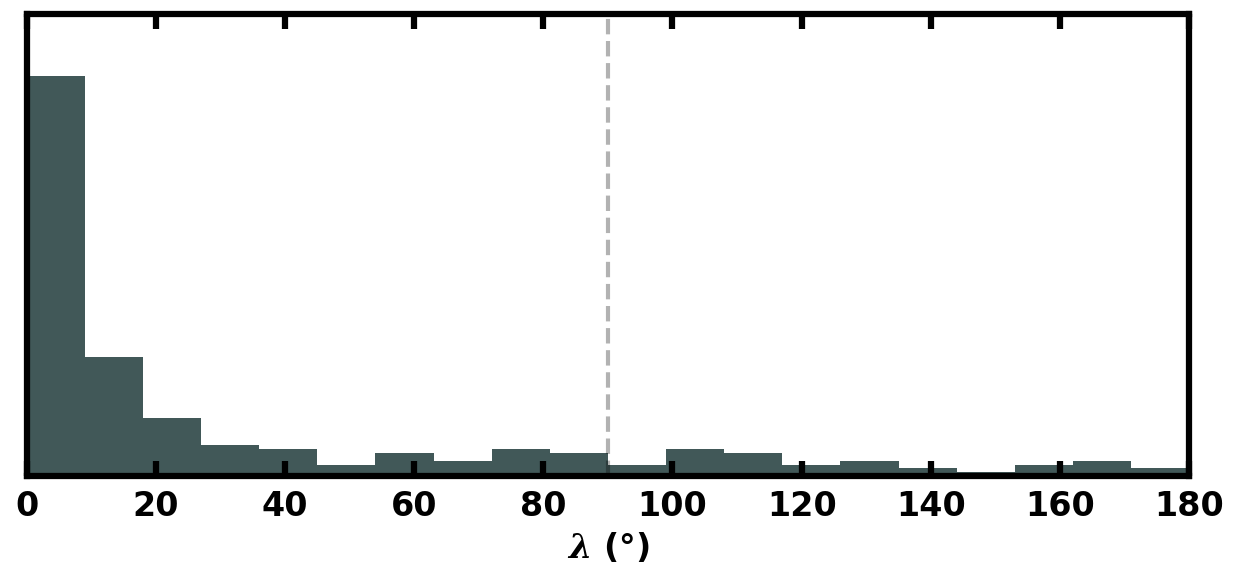

In [5]:
# tepcat = tepcat[tepcat['Lambda'] > 0]
hist_dat = abs(tepcat['Lambda'].values)
hist_dat = hist_dat[hist_dat <= 180]
bins = np.arange(0, 180 + 9, 9)

fig = plt.figure(figsize=(10, 4), dpi=150)
ax = plt.subplot(111)
ax.hist(hist_dat, bins=bins, color='#415858')
ax.plot([90, 90], [0, 120], ls='--', color='#000000', lw=2, alpha=0.30)
ax.set_xlabel(r'$\lambda$ ($\degree$)', fontsize=16)
ax.set_xlim(0, 180)
ax.set_ylim(0, 120)
ax.set_yticks([])
ax.tick_params(labelsize=16)
plt.show()

In [6]:
HJ_results = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Condensed_Sample_By_Date/adopted_highRes_HJ_2024-Dec-04.csv')
WJ_results = pd.read_csv('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Condensed_Sample_By_Date/adopted_highRes_WJ_2024-Dec-04.csv')

HJ_results = HJ_results[HJ_results['Target'] != 'WASP-148']
HJ_results = HJ_results[HJ_results['Target'] != 'K2-281']
HJ_results = HJ_results[HJ_results['Target'] != 'Kepler-1654']
WJ_results = WJ_results[WJ_results['Target'] != 'WASP-148']
WJ_results = WJ_results[WJ_results['Target'] != 'K2-281']
WJ_results = WJ_results[WJ_results['Target'] != 'Kepler-1654']


imaged_Deltai = [1.4, 1.4, 4.0]
imaged_Names = ['PDS 70 b', 'PDS 70 c', 'AF Lep b']

SS_Deltai = [6, 6, 6, 6, 6, 6, 6, 6]  # , 6]
SS_Names = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']  # , 'Pluto']



Pl_Deltai = HJ_results['disk diff'].values
Pl_Names = HJ_results['Target'].values
# Pl_Deltai = np.concatenate((Pl_Deltai, WJ_results['disk diff'].values, imaged_Deltai, SS_Deltai))
# Pl_Names = np.concatenate((Pl_Names, WJ_results['Target'].values, imaged_Names, SS_Names))
Pl_Deltai = np.concatenate((Pl_Deltai, WJ_results['disk diff'].values, imaged_Deltai))
Pl_Names = np.concatenate((Pl_Names, WJ_results['Target'].values, imaged_Names))


Pl_Names

array(['CoRoT-18', 'CoRoT-2', 'HAT-P-20', 'HAT-P-36', 'HATS-2',
       'HD 209458', 'Kepler-17', 'Qatar 2', 'Qatar-1', 'WASP-19',
       'WASP-32', 'WASP-4', 'WASP-41', 'WASP-43', 'WASP-5', 'WASP-52',
       'WASP-6', 'WASP-69', 'WASP-94A', 'XO-2 N', 'K2-139', 'K2-329',
       'K2-77', 'Kepler-27', 'Kepler-28', 'Kepler-289', 'Kepler-30',
       'Kepler-447', 'Kepler-468', 'Kepler-51', 'Kepler-52', 'Kepler-539',
       'Kepler-63', 'Kepler-75', 'Kepler-9', 'TOI-1227', 'TOI-4562',
       'V1298 Tau', 'WASP-84', 'PDS 70 b', 'PDS 70 c', 'AF Lep b'],
      dtype=object)

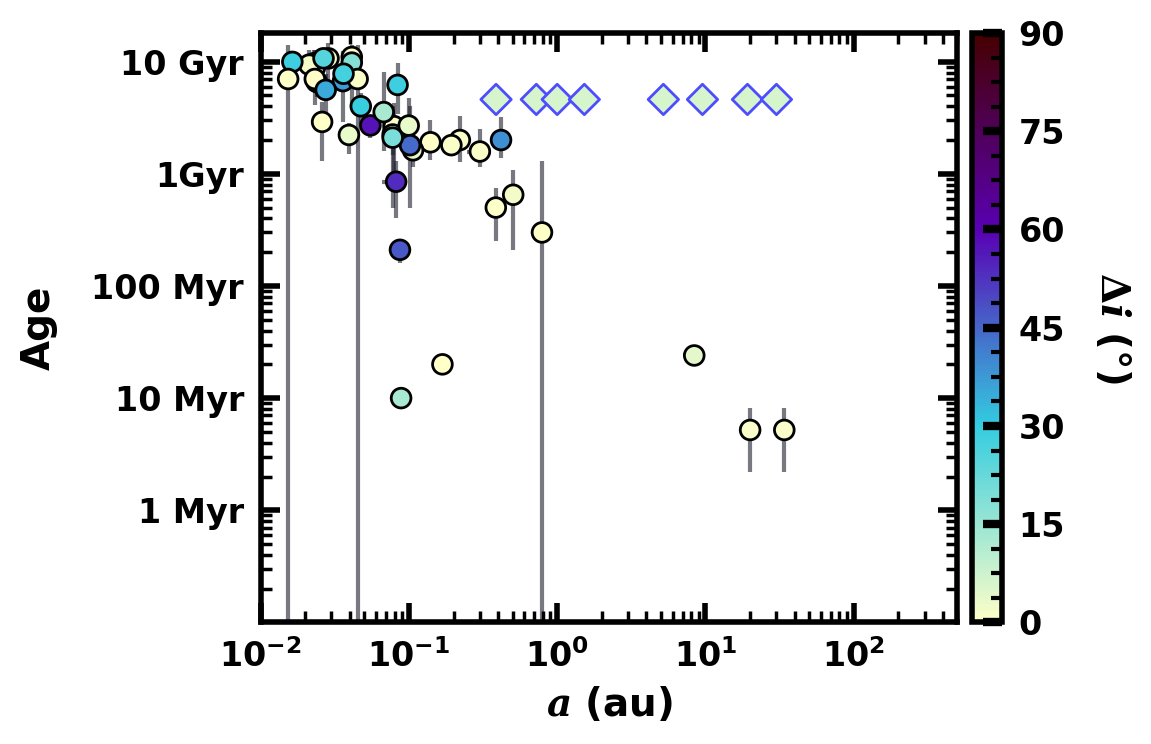

In [7]:
HJs = pd.read_csv("/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/Morgan_HotJupiter_Stars.csv")
WJs = pd.read_csv("/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Tables/Literature_Tables/Morgan_WarmJupiter_Stars.csv")
WJs = WJs[WJs['Target'] != 'K2-281']
WJs = WJs[WJs['Target'] != 'Kepler-1654']

for targ in HJs['Target'].values:
    if targ not in Pl_Names:
        HJs = HJs[HJs['Target'] != targ]
for targ in WJs['Target'].values:
    if targ not in Pl_Names:
        WJs = WJs[WJs['Target'] != targ]


ages_and_seps = {}

targs = HJs['Target'].values
ages = HJs['Age (Gyr)'].values
ages_p = HJs['Age +Unc'].values
ages_m = HJs['Age -Unc'].values
seps = HJs['a (AU)'].values
seps_p = HJs['a (AU) +Unc'].values
seps_m = HJs['a (AU) -Unc'].values

imaged_ages = [5.2e-3, 5.2e-3, 0.024]
imaged_ages_p = [3e-3, 3e-3, 0.003]
imaged_ages_m = [3e-3, 3e-3, 0.003]
imaged_seps = [20, 34, 8.4]
imaged_seps_p = [2, 6, 1.1]
imaged_seps_m = [2, 3, 1.3]

SS_seps = [0.387, 0.723, 1.000, 1.524, 5.20, 9.54, 19.19, 30.1]  # , 39.5]
SS_seps_p = [0, 0, 0, 0, 0, 0, 0, 0]  # , 0]
SS_seps_m = [0, 0, 0, 0, 0, 0, 0, 0]  # , 0]
SS_ages = [4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6]  # , 4.6,]
SS_ages_p = [0, 0, 0, 0, 0, 0, 0, 0]  # , 0]
SS_ages_m = [0, 0, 0, 0, 0, 0, 0, 0]  # , 0]

# targs = np.concatenate((targs, WJs['Target'].values, imaged_Names, SS_Names))
# ages = np.concatenate((ages, WJs['Age (Gyr)'].values, imaged_ages, SS_ages))
# ages_p = np.concatenate((ages_p, WJs['Age +Unc'].values, imaged_ages_p, SS_ages_p))
# ages_m = np.concatenate((ages_m, WJs['Age -Unc'].values, imaged_ages_m, SS_ages_m))
# seps = np.concatenate((seps, WJs['a (AU)'].values, imaged_seps, SS_seps))
# seps_p = np.concatenate((seps_p, WJs['a (AU) +Unc'].values, imaged_seps_p, SS_seps_p))
# seps_m = np.concatenate((seps_m, WJs['a (AU) -Unc'].values, imaged_seps_m, SS_seps_m))

targs = np.concatenate((targs, WJs['Target'].values, imaged_Names))
ages = np.concatenate((ages, WJs['Age (Gyr)'].values, imaged_ages))
ages_p = np.concatenate((ages_p, WJs['Age +Unc'].values, imaged_ages_p))
ages_m = np.concatenate((ages_m, WJs['Age -Unc'].values, imaged_ages_m))
seps = np.concatenate((seps, WJs['a (AU)'].values, imaged_seps))
seps_p = np.concatenate((seps_p, WJs['a (AU) +Unc'].values, imaged_seps_p))
seps_m = np.concatenate((seps_m, WJs['a (AU) -Unc'].values, imaged_seps_m))


for name in Pl_Names:
    if name not in targs:
        print(name)


fig = plt.figure(figsize=(6, 4), dpi=200)
ax = fig.add_subplot(111)
ax.set_xlabel(r'$a$ (au)', fontsize=14)
ax.set_ylabel(r'Age', fontsize=14, labelpad=12)


z_min, z_max = 0, 90
z_norm = plt.Normalize(z_min, z_max)
colormap = choose_cmap('raspberry punch2', reverse_cmap=True)
point_colors = [colormap(z_norm(bep)) for bep in Pl_Deltai]
SS_point_colors = [colormap(z_norm(bep)) for bep in SS_Deltai]

ax.scatter(seps, ages, c=point_colors, marker='o', s=np.pi*(4)**2, edgecolor='#000000', zorder=10)
ax.errorbar(seps, ages, xerr=[seps_m, seps_p], yerr=[ages_m, ages_p], ecolor='#1f1f2e', lw=0, elinewidth=1.5, alpha=0.6, zorder=-10)

ax.scatter(SS_seps, SS_ages, c=SS_point_colors, marker='D', s=60, edgecolor='#4d4dff', zorder=10)


# ax.fill_between([7, 200], [14, 14], color='orange', alpha=0.2, zorder=-20)
# ax.plot([7, 7], [0, 14], ls='--', color='#000000', alpha=0.2, zorder=-20)
# ax.plot([7, 7], [0, 14], ls='--', color='#000000', alpha=0.2, zorder=-20)

cbar_extend = 'neither'
cbar = plt.colorbar(mpl.cm.ScalarMappable(norm=z_norm, cmap=colormap), ax=ax, use_gridspec=True, shrink=1., fraction=0.05, pad=0.02, extend=cbar_extend)  # location='top', 
cbar.set_label(r'$\Delta i$ ($\degree$)', labelpad=24, rotation=270, fontsize=14, weight='bold')
cbar_ticks = np.arange(0, 90 + 15, 15)
cbar.set_ticks(cbar_ticks)
cbar_ticklabels = [str(cbar_tick) for cbar_tick in cbar_ticks]
cbar.set_ticklabels(cbar_ticklabels, fontsize=12)
cbar.minorticks_on()
cbar.outline.set_linewidth(2)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-2, 500)
ax.set_ylim(1e-4, 18)

ax.set_yticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_yticklabels(['1 Myr', '10 Myr', '100 Myr', '1Gyr', '10 Gyr'], fontsize=12)

ax.tick_params(axis='x', which='major', size=7, labelsize=12, width=2)
ax.tick_params(axis='x', which='minor', size=4, labelsize=12, width=1.25)
ax.tick_params(axis='y', which='major', size=7, labelsize=12, width=2)
ax.tick_params(axis='y', which='minor', size=4, labelsize=12, width=1.25)
for spine in ax.spines.values():
    spine.set_linewidth(2)

# fig.subplots_adjust(left=0.25, bottom=0.15, right=0.97, top=0.98, wspace=0, hspace=0)
plt.tight_layout()

plt.savefig('/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/Test_Figures/Sep_vs_age.png', transparent=True)

plt.show()
plt.close()





In [8]:
HJs.columns

Index(['Subset', 'Target', 'Prot (d)', 'Prot +Unc', 'Prot -Unc',
       'Prot Reference', 'vsini (km/s)', 'vsini (km/s).1', 'vsini Unc',
       'vsini Reference', 'i star (deg)', 'i star +Unc', 'i star -Unc',
       'i star Reference', 'a/Rstar', 'a/Rstar +Unc', 'a/Rstar -Unc',
       'Rstar (Rsun)', 'Rstar +Unc', 'Rstar -Unc', 'a (AU)', 'a (AU) +Unc',
       'a (AU) -Unc', 'Teff (K)', 'Teff +Unc', 'Teff -Unc', 'Teff Reference',
       'Age (Gyr)', 'Age +Unc', 'Age -Unc', 'Age Reference', 'References'],
      dtype='object')

In [10]:
def true_obliquity_posterior(i_star_deg, i_plane_deg, dx, verbose=False):
    # Compute the posterior distribution conditioned on the stellar inclination angle and inclination of the disk or orbital plane

    if verbose == True:
        print('i_star_deg', i_star_deg)
        print('i_plane_deg', i_plane_deg)
        print('abs(i_plane_deg - i_star_deg): ', abs(i_plane_deg - i_star_deg))
        print('i_plane_deg + i_star_deg: ', i_plane_deg + i_star_deg)


    all_obliquities_deg = np.arange(0, 180+dx, dx)

    all_obliquities_rad = []
    for obl in range(len(all_obliquities_deg)):
        all_obliquities_rad.append(np.radians(all_obliquities_deg[obl]))
    # all_obliquities_rad = np.array(all_obliquities_rad)

    i_star_rad = np.radians(i_star_deg)
    i_plane_rad = np.radians(i_plane_deg)


    posterior = []
    for rad in all_obliquities_rad:
        top = np.sin(i_star_rad) * np.sin(rad)
        bottom1 = (np.sin(rad) * np.sin(rad)) * (np.sin(i_plane_rad) * np.sin(i_plane_rad))
        bottom2 = ((np.cos(rad) * np.cos(i_plane_rad)) - np.cos(i_star_rad))**2
        # if np.isnan(top / np.sqrt(bottom1 - bottom2)) == False:
        #     print(top / np.sqrt(bottom1 - bottom2))
        posterior.append(top / np.sqrt(bottom1 - bottom2))

    posterior = np.array(posterior)

    # posterior[np.isnan(posterior) == False][0] = float('nan')
    posterior[np.isnan(posterior) == True] = 0

    done_flag = 0
    for fart in range(len(posterior)):
        if done_flag == 1:
            break
        else:
            if posterior[fart] > 0:
                posterior[fart] = 0
                done_flag = 1
            
    posterior = posterior / (sum(posterior) * dx)

    return all_obliquities_deg, posterior

In [78]:
dx = 0.1

# regrograde_fraction = 0.4

np.random.seed(44644)
seed(44644)

n_trials = 100000  # int(1e4) # int(8e4) # * 49  # 100 * 49

save_output = True


do_independent = True
if do_independent == False:
    do_aligned = True
else:
    do_aligned = False

# istars = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
# if do_totally_independent == True:
#     idisks = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
# if do_totally_aligned == True:
#     idisks = np.copy(istars)
# if do_fixed_idisks == True:
#     idisks = [90]*len(istars)

# istars_initial = [44]
# idisks_initial = [40]


if do_independent == True:
    possible_is = np.arange(0, 180 + dx, dx)
if do_aligned == True: 
    possible_is = np.arange(80, 180 + dx, dx)

i_prob_dist = np.sin(np.radians(possible_is))

impose_observer_shift = False
if impose_observer_shift == True:
    istars_initial = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
    idisks_initial = choices(population=possible_is, weights=i_prob_dist, k=n_trials)

    i_offsets = []
    for offset_i in range(0, len(idisks_initial)):
        i_offsets.append(90 - idisks_initial[offset_i])

    istars = np.array(istars_initial) + np.array(i_offsets)
    idisks = np.array(idisks_initial) + np.array(i_offsets)

    for draw_i in range(len(istars)):
        if istars[draw_i] > 90:
            istars[draw_i] = 90 - abs(istars[draw_i] - 90)
        if idisks[draw_i] > 90:
            idisks[draw_i] = 90 - abs(idisks[draw_i] - 90)
else:
    istars = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
    idisks = choices(population=possible_is, weights=i_prob_dist, k=n_trials)


# idisks = [0, 15, 30, 45, 60, 75, 90]
# istars = [100] * len(idisks)

icolors = ['red', 'orange', 'gold', 'green', 'blue', 'purple', 'pink']
  

# kde_n_draws = 10  # 360  # int(5e2)
# kde_bandwidth = 5.63


master_Deltais = []

maxval = 0

# test_fig1 = plt.figure(figsize=(6.5, 5), dpi=150)
# test_fig_ax = test_fig1.add_subplot(111)
# test_fig_ax.minorticks_on()

# # test_fig_ax.set_title('First random draw for each target', pad=8)
# test_fig_ax.set_xlabel(r'$\Psi$ ($\degree$)')
# test_fig_ax.set_ylabel(r'$P(\Psi$ | $i_{*}, i_{\mathrm{disk}})$')

Psi_draws = []
num_draws = 10

Psis = []

for bep in range(len(istars)):
    # print("{:.2f}%".format((bep+1)/len(istars)))

    istar = istars[bep]
    idisk = idisks[bep]


    master_Deltais.append(abs(istar - idisk))


    Psi, Prob_Psi = true_obliquity_posterior(i_star_deg=istar, i_plane_deg=idisk, dx=dx, verbose=False)  # , verbose=True)

    if max(Prob_Psi) > 1:
        Prob_Psi[np.where(Prob_Psi > 1)[0]] = 0

    Psis.append(Prob_Psi)

    if sum(Prob_Psi) == 0:
        print('istar', istar)
        print('idisk', idisk, '\n')
        Psi_draw = [90.]*num_draws
    else:
        Psi_draw = choices(population=Psi, weights=Prob_Psi, k=num_draws)
    
    Psi_draws.extend(Psi_draw)

    # all_Psi.append(Prob_Psi)

    # if bep < 44:
        # print(istar)
        # print(idisk)
    if max(Prob_Psi) > maxval:
        maxval = max(Prob_Psi)
        
        
    bepcolor = 'blue'
    bep_lw = 3

    # test_fig_ax.plot(Psi, Prob_Psi, color=bepcolor, linewidth=bep_lw, alpha=1)

        # if max(Prob_Psi) > 5:
        #     print(istar)
        #     print(idisk)

        #     plot_psi = Psi[np.where(Prob_Psi > 0)[0][1:]]
        #     plot_prob_psi = Prob_Psi[np.where(Prob_Psi > 0)[0][1:]]

        #     test_fig_ax.plot(plot_psi, plot_prob_psi, color=bepcolor, linewidth=bep_lw, alpha=1)

    # if bep == 1:
    #     bepcolor = 'red'
    #     bep_lw = 1

    
# Psi_draws = draw_data_for_kde(Prob_distributions=all_Psi, posterior_x_values=Psi, kde_n_draws=kde_n_draws)  # , verbose=True)

# Psi_kde = generate_kde(Psi_draws, Psi, dx, kde_bandwidth)


/var/folders/d1/1tgqc089191cw1n9by3bdp_nm479yx/T/ipykernel_9819/3034387279.py:29: RuntimeWarning: invalid value encountered in sqrt
  posterior.append(top / np.sqrt(bottom1 - bottom2))
/var/folders/d1/1tgqc089191cw1n9by3bdp_nm479yx/T/ipykernel_9819/3034387279.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  posterior.append(top / np.sqrt(bottom1 - bottom2))
/var/folders/d1/1tgqc089191cw1n9by3bdp_nm479yx/T/ipykernel_9819/3034387279.py:45: RuntimeWarning: invalid value encountered in divide
  posterior = posterior / (sum(posterior) * dx)
/var/folders/d1/1tgqc089191cw1n9by3bdp_nm479yx/T/ipykernel_9819/3034387279.py:29: RuntimeWarning: invalid value encountered in scalar divide
  posterior.append(top / np.sqrt(bottom1 - bottom2))


istar 86.2
idisk 0.4 

istar 57.900000000000006
idisk 179.70000000000002 

istar 179.8
idisk 174.10000000000002 

istar 179.60000000000002
idisk 130.6 

istar 135.20000000000002
idisk 179.8 

istar 32.4
idisk 179.60000000000002 

istar 99.9
idisk 179.70000000000002 

istar 113.7
idisk 0.2 

istar 40.900000000000006
idisk 179.70000000000002 

istar 158.9
idisk 179.70000000000002 



/var/folders/d1/1tgqc089191cw1n9by3bdp_nm479yx/T/ipykernel_9819/3458529869.py:9: RuntimeWarning: invalid value encountered in divide
  test_fig_ax.plot(Psi, Psis[bla]/max(Psis[bla]), color=icolors[bla], linewidth=bep_lw, alpha=1)


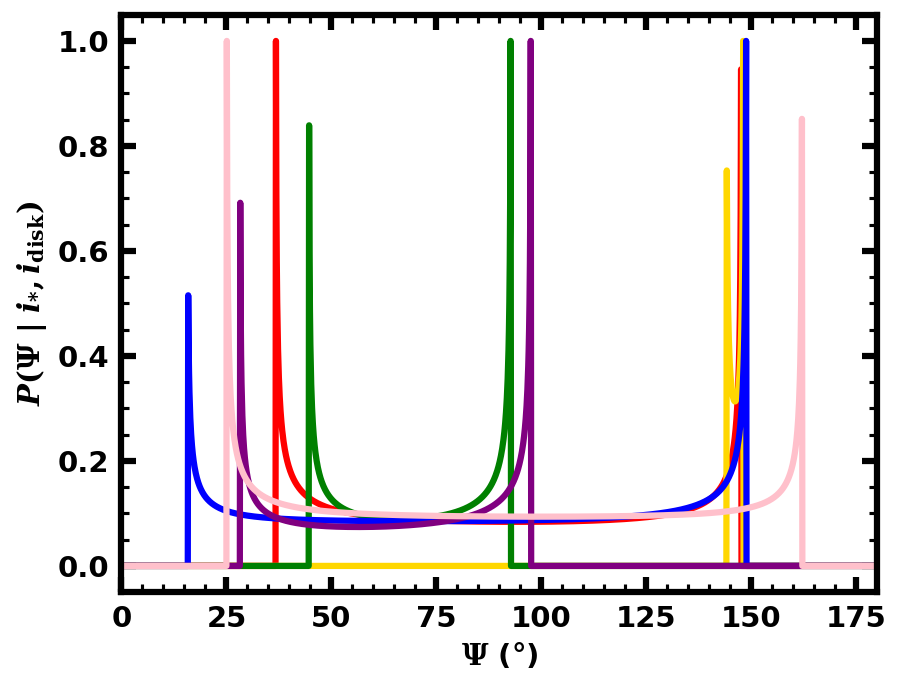

In [70]:
test_fig1 = plt.figure(figsize=(6.5, 5), dpi=150)
test_fig_ax = test_fig1.add_subplot(111)
test_fig_ax.minorticks_on()

# test_fig_ax.set_title('First random draw for each target', pad=8)
test_fig_ax.set_xlabel(r'$\Psi$ ($\degree$)')
test_fig_ax.set_ylabel(r'$P(\Psi$ | $i_{*}, i_{\mathrm{disk}})$')
for bla in range(len(Psis[:7])):
    test_fig_ax.plot(Psi, Psis[bla]/max(Psis[bla]), color=icolors[bla], linewidth=bep_lw, alpha=1)
    # test_fig_ax.plot(Psi, Psis[bla], color=icolors[bla], linewidth=bep_lw, alpha=1)
# test_fig_ax.plot([90, 90], [0, 1.15], ls='--', color='#000000', alpha=0.40, lw=1.5, zorder=-100)
# test_fig_ax.set_ylim(-0.02, 1.15)
test_fig_ax.set_xlim(0, 180)  # 180)
plt.show()
plt.close()

In [71]:
save_path = '/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/True_Obliquity_Tests/Psi_Draws_Theoretical/'
save_master_filename = 'Random_i_Draws_Theoretical_'
save_Psi_filename = 'Psi_Results_Theoretical_Draws_'

import os
import re
def list_files_in_dir(dirpath):
    initial_file_list = [file1 for file1 in os.listdir(dirpath) if os.path.isfile(os.path.join(dirpath, file1))]
    return_file_list = [file2 for file2 in initial_file_list if '_Theoretical_' in file2]
    return return_file_list

file_list = list_files_in_dir(dirpath=save_path)
print('Initial File List:\n', file_list)
if len(file_list) == 0:
    save_master_filename += '0'
    save_Psi_filename += '0'
if len(file_list) > 0:
    file_list = sorted_alphanumeric(list_to_sort=file_list)
    last_file = file_list[-1].split('.')[0]
    last_filenum = int(last_file[-1])
    save_master_filename += str(last_filenum + 1)
    save_Psi_filename += str(last_filenum + 1)

save_master_dict = {'master_istars': istars,
             'master_idisks': idisks,
             'master_Deltais': master_Deltais,
             }
save_Psi_dict = {
             'Psi_draws': Psi_draws,
             }
save_master_df = pd.DataFrame(save_master_dict)
save_Psi_df = pd.DataFrame(save_Psi_dict)
save_master_df.to_csv(save_path + save_master_filename + '.csv', index=False)
save_Psi_df.to_csv(save_path + save_Psi_filename + '.csv', index=False)

Initial File List:
 ['Psi_Results_Theoretical_Draws_1.csv', 'Psi_Results_Theoretical_Draws_0.csv', 'Psi_Results_Theoretical_Draws_2.csv', 'Random_i_Draws_Theoretical_4.csv', 'Psi_Results_Theoretical_Draws_3.csv', 'Random_i_Draws_Theoretical_1.csv', 'Random_i_Draws_Theoretical_0.csv', 'Psi_Results_Theoretical_Draws_4.csv', 'Random_i_Draws_Theoretical_2.csv', 'Random_i_Draws_Theoretical_3.csv']


In [72]:
file_list_2 = list_files_in_dir(dirpath=save_path)
file_list_2 = sorted_alphanumeric(list_to_sort=file_list_2)
last_file_2 = file_list_2[-1].split('.')[0]
last_filenum_2 = int(last_file_2[-1])
filenums = np.arange(0, last_filenum_2 + 1, 1)

istars_2 = []
idisks_2 = []
master_Deltais_2 = []
Psi_draws_2 = []

read_master_filename = 'Random_i_Draws_Theoretical_'
read_Psi_filename = 'Psi_Results_Theoretical_Draws_'

for filenum in filenums:
    read_master_filepath = save_path + read_master_filename + str(filenum) + '.csv'
    read_Psi_filepath = save_path + read_Psi_filename + str(filenum) + '.csv'
    master_df = pd.read_csv(read_master_filepath)
    Psi_df = pd.read_csv(read_Psi_filepath)
    istars_2.extend(master_df['master_istars'].values)
    idisks_2.extend(master_df['master_idisks'].values)
    master_Deltais_2.extend(master_df['master_Deltais'].values)
    Psi_draws_2.extend(Psi_df['Psi_draws'].values)



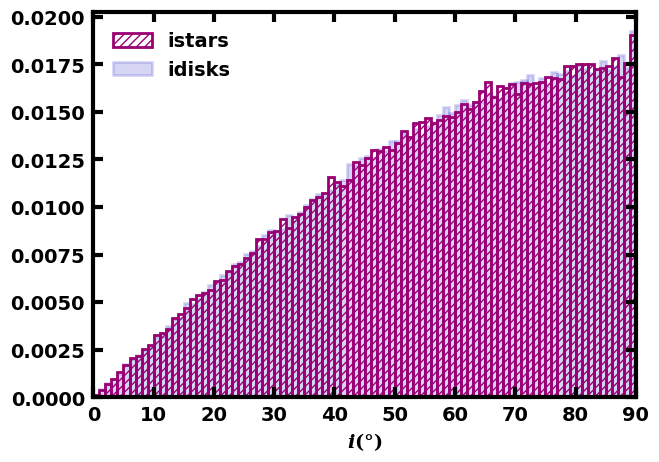

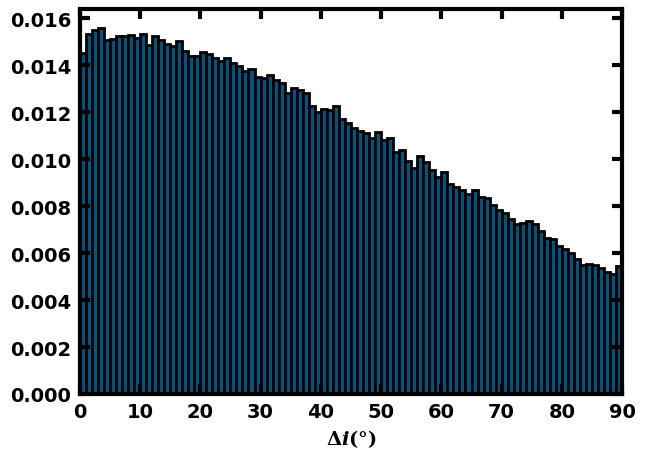

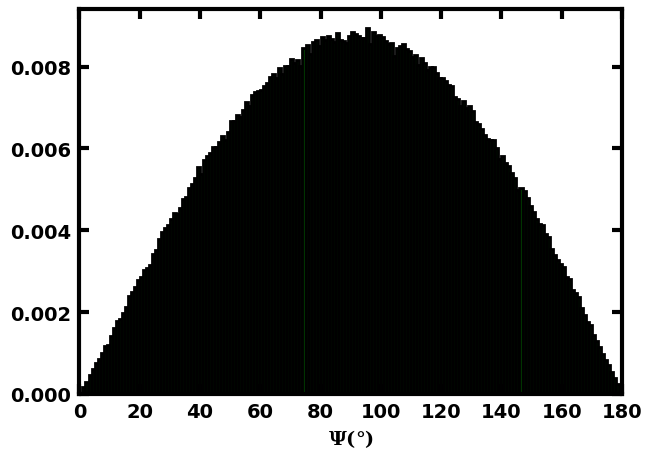

In [73]:
bin_width = 1
hist_bins = np.arange(0, 90 + bin_width, bin_width)
plt.hist(istars_2, edgecolor='#990073', hatch='////', lw=2, fill=False, bins=hist_bins, density=True, label='istars')
plt.hist(idisks_2, edgecolor='#3333cc', color='#3333cc', lw=2, fill=True, bins=hist_bins, alpha=0.2, density=True, label='idisks', zorder=-100)
plt.xlim(0, 90)
plt.xlabel(r'$i  (\degree)$')
plt.legend(loc='upper left')
plt.show()
plt.close()



power, bounds = np.histogram(master_Deltais_2, bins=np.arange(0, 90+bin_width, bin_width))
power = power/(np.sum(power) * bin_width)
Deltai_x = bounds[:-1]

Deltai_color = '#005580'
plt.bar(bounds[:-1], power, edgecolor='#000000', color=Deltai_color, lw=2, align='edge', width=bin_width)
plt.xlim(0, 90)
plt.xlabel(r'$\Delta i  (\degree)$')
plt.show()
plt.close()

Psi_bin_width = 1
Psi_bin_edges = np.arange(0, 180, Psi_bin_width)
Psi_power, Psi_bounds = np.histogram(Psi_draws, bins=Psi_bin_edges, density=True)
Psi_x = Psi_bounds
# Psi_x = Psi_x + 0.5*np.diff(Psi_x)[0]
Psi_power = np.concatenate((Psi_power, [0]))

# print(Psi_bounds)
# print(Psi_power)

Psi_color = '#003300'
plt.bar(Psi_x, Psi_power, edgecolor='#000000', color=Psi_color, lw=2, align='edge', width=Psi_bin_width)
# plt.hist(Psi_draws, bins=Psi_bin_edges, density=True)
plt.xlim(0, 180)
plt.xlabel(r'$\Psi (\degree)$')
plt.show()
plt.close()

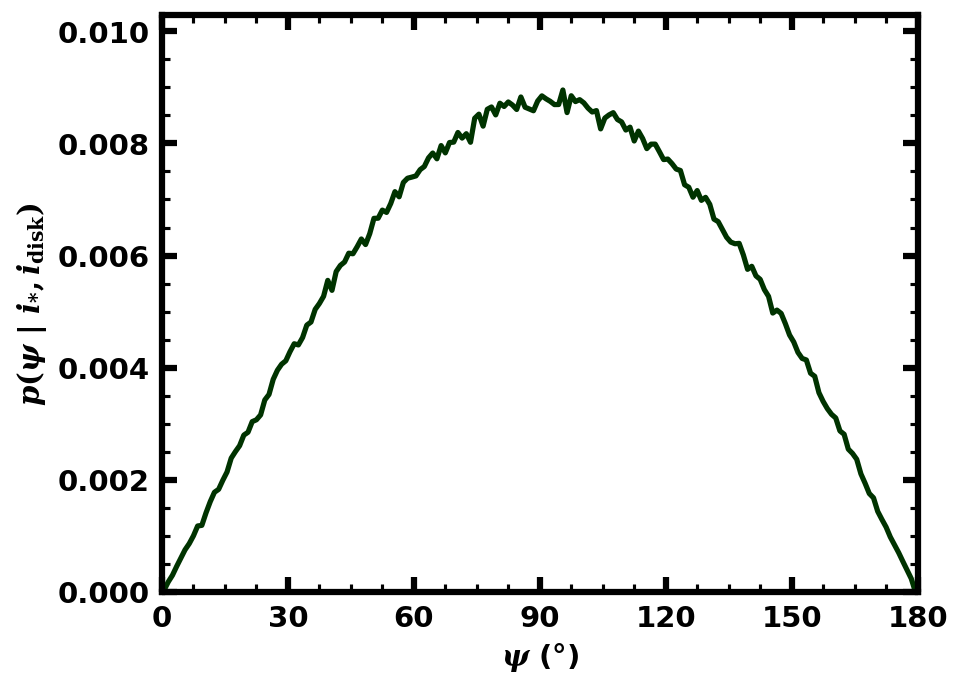

In [74]:
test_fig = plt.figure(figsize=(6.5, 5), dpi=150)
ax = test_fig.add_subplot(111)
ax.minorticks_on()

# ax.set_title(r'$i_{\ast}$ = ' + '{:.1f}'.format(istar) + r'$\degree$    ' + r'$i_{\mathrm{disk}}$ = ' + '{:.1f}'.format(idisk) + r'$\degree$    ' + r'$\Delta i$ = ' + '{:.1f}'.format(abs(istar - idisk)) + r'$\degree$    ', pad=8, x=0.6)
ax.set_xlabel(r'$\psi$ ($\degree$)')
ax.set_ylabel(r'$p(\psi$ | $i_{*}, i_{\mathrm{disk}})$')

xmin, xmax = -0, 180
# ymin, ymax = 0, 1.3*max([max(Psi_power), max(Psi_kde)])  # 4*np.mean([blarb for foop in true_obliquities_no_retro_prior for blarb in foop])  # -0.04 * max(ploty), 1.14 * max(ploty)
ymin, ymax = 0, 1.15*np.nanmax(Psi_power) 

linecolor = '#809966'  # '#476685'
fillcolor = '#cccc00'  # '#476685'

# ax.plot(Deltai_x, Deltai_kde, color=Deltai_color, label=r'$\Delta i$')

# ax.plot(Psi, Psi_kde, color='#003300', label=r'$P(\Psi|i_{*}, i_{\circ})$')
ax.plot(Psi_x+0.5*Psi_bin_width, Psi_power, color='#003300')
# ax.fill_between(Psi[1:], Psi_kde_no_retro_prior, color=fillcolor, alpha=0.4, label='no retro. prior')

# ax.plot(Psi[1:], Psi_kde_yes_retro_prior, color='#d9b3ff', label=r'$P(\Psi|i_{*}, i_{\circ})$' + '\nRet. Prior')
# ax.fill_between(Psi[1:], Psi_kde_yes_retro_prior, color='#d9b3ff', alpha=0.4, label='yes retro. prior')

# ax.plot([90, 90], [0, ymax], lw=1, color='#000000', alpha=0.4, zorder = -10)
# ax.text(90 - 5, 0.96 * ymax, 'Prograde', horizontalalignment='center', verticalalignment='top', fontsize=12, rotation=90, color='#000000', alpha=0.4)
# ax.text(90 + 5, 0.96 * ymax, 'Retrograde', horizontalalignment='center', verticalalignment='top', fontsize=12, rotation=270, color='#000000', alpha=0.4)




ax.set_xlim(xmin, 180)
ax.set_ylim(ymin, ymax)

ax.set_xticks([0, 30, 60, 90, 120, 150, 180])

# ax.legend(loc='upper right', fontsize=12)

plt.show()
plt.close()



save_dir = '/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/True_Obliquity_Tests/Psi_Draws_Theoretical/'
if do_independent == True:
    save_file = 'Psi_isotropic_independent.csv'
if do_aligned == True:
    save_file = 'Psi_isotropic_aligned.csv'

Psi_dict = {'Psi': Psi_x,
            'P(Psi)': Psi_power,
            }
Psi_df = pd.DataFrame(Psi_dict)

save_output = True
if save_output == True:
    Psi_df.to_csv(save_dir + save_file, index=False)

In [75]:
def highest_density_interval(x, pdf_y, sigma=0.6826, type='mode', return_pdf=False):
    # 1sigma makes sigma = 0.6826

    x_interp = np.arange(min(x), max(x)+0.001, 0.001)
    pdf_y = np.interp(x=x_interp, xp=x, fp=pdf_y)
    x = x_interp

    cdf_y = np.cumsum(pdf_y)
    cdf_y = cdf_y / cdf_y[-1]  # Normalize the cdf so that it sums to 1.

    sub_cdf = abs(cdf_y - 0.5)
    where_med = np.where(sub_cdf == min(sub_cdf))[0]
    median = np.median(x[where_med])

    delta_xlist = []
    xlower = []
    xupper = []

    sigma_lower = 0
    delta = 1e-6

    for _ in range(0,round((1 - sigma)/delta)):
        x1 = np.interp(sigma_lower,cdf_y,x)
        xu = np.interp(sigma,cdf_y,x)
        delta_xlist.append(xu-x1)
        xlower.append(x1)
        xupper.append(xu)
        sigma += delta
        sigma_lower += delta

    index = delta_xlist.index(min(delta_xlist))
    mode = np.mean(x[pdf_y == max(pdf_y)]).round(1)
    mode = x[pdf_y == max(pdf_y)]
    if len(mode) > 1:
        mode = np.mean(mode)
    else:
        mode = mode[0]
    # print('The lower x value (for minimum credible interval) is ', xlower[index])
    # print('The upper x value (for minimum credible interval) is ', xupper[index])


    if type == 'mode':
        report_val = mode
    if type == 'median':
        report_val = median

    lower = report_val - xlower[index]
    upper = xupper[index] - report_val

    if return_pdf == True:
        return report_val, lower, upper, x, pdf_y
    if return_pdf == False:
        return report_val, lower, upper


In [76]:
save_dir_theoretical = '/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/True_Obliquity_Tests/Psi_Draws_Theoretical/'
save_dir_observed = '/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/True_Obliquity_Tests/Psi_Draws_From_Observations/'

Psi_isotropic = pd.read_csv(save_dir_theoretical + 'Psi_isotropic_independent.csv')
# Psi_isotropic_aligned = pd.read_csv(save_dir + 'Psi_isotropic_aligned.csv')

Psi_observed = pd.read_csv(save_dir_observed + 'Psi_From_Observations.csv')

Isotropic_hdi, Isotropic_hdi_lower, Isotropic_hdi_upper = highest_density_interval(x=Psi_isotropic['Psi'].values, pdf_y=Psi_isotropic['P(Psi)'].values, sigma=0.6826, type='median', return_pdf=False)
# Isotropic_aligned_hdi, Isotropic_aligned_hdi_lower, Isotropic_aligned_hdi_upper = highest_density_interval(x=Psi_isotropic_aligned['Psi'].values, pdf_y=Psi_isotropic_aligned['P(Psi)'].values, sigma=0.6826, type='median', return_pdf=False)
Observed_hdi, Observed_hdi_lower, Observed_hdi_upper = highest_density_interval(x=Psi_observed['Psi'].values, pdf_y=Psi_observed['P(Psi)'].values, sigma=0.6826, type='median', return_pdf=False)

# print(Isotropic_hdi, Isotropic_hdi_lower, Isotropic_hdi_upper)
# print(Isotropic_aligned_hdi, Isotropic_aligned_hdi_lower, Isotropic_aligned_hdi_upper)
# print(Observed_hdi, Observed_hdi_lower, Observed_hdi_upper)



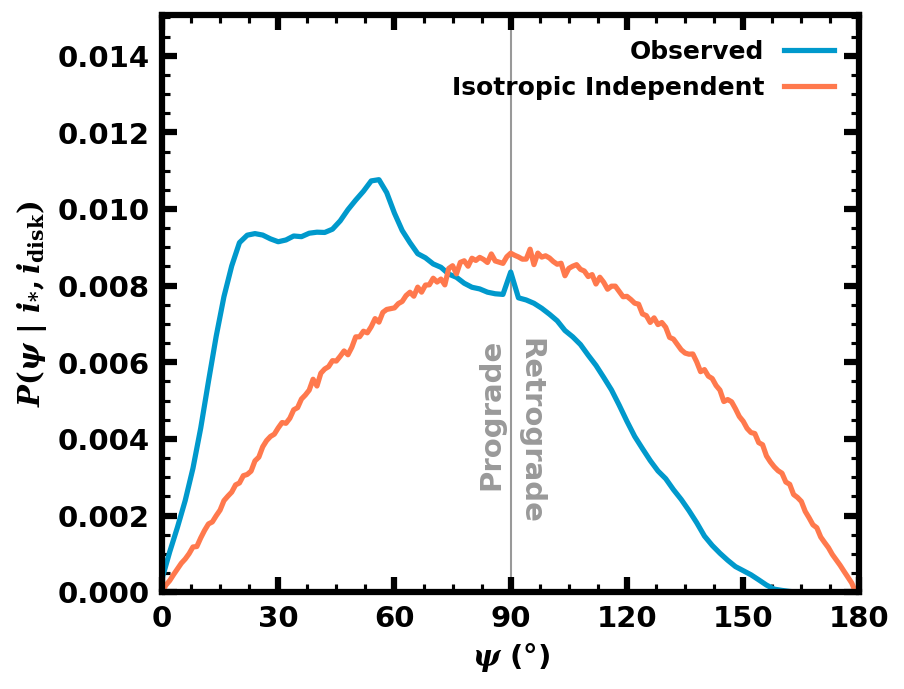

In [77]:
test_fig = plt.figure(figsize=(6, 5), dpi=150)
ax = test_fig.add_subplot(111)
ax.minorticks_on()

# ax.set_title(r'$i_{\ast}$ = ' + '{:.1f}'.format(istar) + r'$\degree$    ' + r'$i_{\mathrm{disk}}$ = ' + '{:.1f}'.format(idisk) + r'$\degree$    ' + r'$\Delta i$ = ' + '{:.1f}'.format(abs(istar - idisk)) + r'$\degree$    ', pad=8, x=0.6)
ax.set_xlabel(r'$\psi$ ($\degree$)')
ax.set_ylabel(r'$P(\psi$ | $i_{*}, i_{\mathrm{disk}})$')

xmin, xmax = -0, 180
ymin, ymax = 0, 1.4*max(Psi_observed['P(Psi)'].values)  # 4*np.mean([blarb for foop in true_obliquities_no_retro_prior for blarb in foop])  # -0.04 * max(ploty), 1.14 * max(ploty)
# print(ymin, ymax)

linecolor = '#809966'  # '#476685'
fillcolor = '#cccc00'  # '#476685'

Psi_isotropic['P(Psi)'].values[-1] = 0
Psi_isotropic['P(Psi)'].values[0] = 0

# Psi_isotropic_aligned['P(Psi)'].values[-1] = 0
# Psi_isotropic_aligned['P(Psi)'].values[0] = 0

ax.plot(Psi_observed['Psi'].values, Psi_observed['P(Psi)'].values, color='#0099cc', label='Observed')

ax.plot(Psi_isotropic['Psi'].values, Psi_isotropic['P(Psi)'].values, color='#ff794d', label='Isotropic Independent')

# ax.plot(Psi_isotropic_aligned['Psi'].values+0.75, Psi_isotropic_aligned['P(Psi)'].values, color='#7300e6', label='Isotropic Aligned')





ax.plot([90, 90], [0, ymax], lw=1, color='#000000', alpha=0.4, zorder = -10)
ax.text(90 - 5, 0.44 * ymax, 'Prograde', horizontalalignment='center', verticalalignment='top', fontsize=14, rotation=90, color='#000000', alpha=0.4)
ax.text(90 + 5, 0.44 * ymax, 'Retrograde', horizontalalignment='center', verticalalignment='top', fontsize=14, rotation=270, color='#000000', alpha=0.4)

ax.set_xlim(xmin, 180)
ax.set_ylim(ymin, ymax)

ax.set_xticks([0, 30, 60, 90, 120, 150, 180])

ax.legend(loc='upper right', fontsize=12, markerfirst=False)

plt.show()
plt.close()



# save_dir = '/Users/lib278/Documents/Manuscripts/OBLIQUITY_SYNTHESIS/True_Obliquity_Tests/'
# if do_totally_independent == True:
#     save_file = 'Psi_isotropic_independent.csv'
# if do_totally_aligned == True:
#     save_file = 'Psi_isotropic_aligned.csv'

# Psi_dict = {'Psi': Psi,
#             'KDE': Psi_kde_no_retro_prior,
#             }
# Psi_df = pd.DataFrame(Psi_dict)

# Psi_df.to_csv(save_dir + save_file, index=False)

In [229]:
# dx = 0.1
# possible_is = np.arange(dx, 90 + dx, dx)
# i_prob_dist = np.sin(np.radians(possible_is))
# possible_Psis = np.arange(dx, 180 + dx, dx)

# # regrograde_fraction = 0.4

# np.random.seed(44)
# seed(44)

# n_trials = 10

# save_output = False


# do_totally_independent = True
# do_totally_aligned = False
# do_fixed_idisks = False

# istars = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
# if do_totally_independent == True:
#     idisks = choices(population=possible_is, weights=i_prob_dist, k=n_trials)
# if do_totally_aligned == True:
#     idisks = np.copy(istars)
# if do_fixed_idisks == True:
#     idisks = [90]*len(istars)



# retro_draws = choices(population=np.arange(0, 1.0, 0.001), k=n_trials)
# # retro_draws = np.random.uniform(0., 1.0, size=n_trials)

# # istars = [40, 44]
# # idisks = [90, 90]
# # retro_draws = [0.7]
  

# kde_n_draws = int(1e3)
# kde_bandwidth = 6

# true_obliquities_no_retro_prior = []
# true_obliquities_yes_retro_prior = []
# minimum_obliquities = []
# maxval = 0

# for bep in range(len(istars)):
#     # print("{:.2f}%".format((bep+1)/len(istars)))

#     istar = istars[bep]
#     idisk = idisks[bep]


#     minimum_obliquities.append(abs(istar - idisk))


#     Psi, Prob_Psi = true_obliquity_posterior(i_star_deg=istar, i_plane_deg=idisk, dx=dx)  # , verbose=True)

#     Prob_Psi_copy = np.copy(Prob_Psi)

#     true_obliquities_no_retro_prior.append(Prob_Psi)

#     if bep == 0 or bep == 1:
#         print(istar)
#         print(idisk)
#         # print(retro_draws[bep])
#         Prob_Psi = Prob_Psi / (sum(Prob_Psi) * dx)
#         if bep == 0:
#             bepcolor = 'blue'
#             bep_lw = 3
#         if bep == 1:
#             bepcolor = 'red'
#             bep_lw = 1

    
#     plt.plot(Psi, Prob_Psi, color=bepcolor, linewidth=bep_lw, alpha=1)
    
#     # if retro_draws[bep] <= regrograde_fraction:
#     #     # mirrored_portion = Prob_Psi[Psi <= 90][::-1]
#     #     # Prob_Psi[Psi >= 90] += mirrored_portion
#     #     Prob_Psi_copy[Psi < 90] = 0.0
#     # else:
#     #     # mirrored_portion = Prob_Psi[Psi >= 90][::-1]
#     #     # Prob_Psi[Psi <= 90] += mirrored_portion
#     #     Prob_Psi_copy[Psi > 90] = 0.0

#     if len(Prob_Psi_copy > 0) > 0:
#         Prob_Psi_copy = Prob_Psi_copy / (np.sum(Prob_Psi_copy) * dx)
#         true_obliquities_yes_retro_prior.append(Prob_Psi_copy)
    
#     # plt.plot(Psi, Prob_Psi, color='blue', alpha=0.08)
    
#     if max(Prob_Psi) > maxval:
#         maxval = max(Prob_Psi)

#     # if bep != len(istars):
#     #     clear_output()

# plt.ylim(0, 1.2*max([blarb for foop in true_obliquities_no_retro_prior for blarb in foop]))
# plt.plot([90, 90], [0, 1.2*max([blarb for foop in true_obliquities_no_retro_prior for blarb in foop])], ls='--', color='#000000', alpha=0.40, lw=1.5, zorder=-100)
# plt.xlim(-10, 185)
# plt.show()
    
# data_for_Psi_kde_no_retro_prior = draw_data_for_kde(Prob_distributions=true_obliquities_no_retro_prior, posterior_x_values=Psi, kde_n_draws=kde_n_draws)  # , verbose=True)
# data_for_Psi_kde_yes_retro_prior = draw_data_for_kde(Prob_distributions=true_obliquities_yes_retro_prior, posterior_x_values=Psi, kde_n_draws=kde_n_draws)  # , verbose=True)

# Psi_kde_no_retro_prior = generate_kde(data_for_Psi_kde_no_retro_prior, Psi, dx, kde_bandwidth)
# Psi_kde_yes_retro_prior = generate_kde(data_for_Psi_kde_yes_retro_prior, Psi, dx, kde_bandwidth)
